In [1]:
import pandas as pd
import numpy as np
import random

import datetime

import re
from nltk.tokenize import sent_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
from matplotlib import cm

from itertools import combinations

In [2]:
long = pd.read_pickle('all_comments.pickle')     #loading all comments collected
long.head()

,text,author,date,group,language
0,imagine asking for exo tickets for your birthd...,Annaliese Bain,2016-07-14,expedition,en
1,They're not terrible at singing or anything bu...,Katherine Wells,2017-04-17,expedition,en
2,those weird crying pictures are terrifying wtf,Emily T,2017-04-21,expedition,en
3,Why is literally nobody talking about how they...,mina,2020-04-04,expedition,en
4,i wanna know what kpop idols think about this,johnhyuck,2017-04-18,expedition,en


In [3]:
df = pd.DataFrame(columns=['group'])

for g in long['group'].unique():
    df.at[df.shape[0], 'group'] = g

df = df.set_index('group')

for g in long['group'].unique():    
    result = long.groupby('group')['language'].value_counts(normalize=True).loc[g][:3]
    
    for i in result.index:
        num = round(result[i], 3)
        df.at[g, i] = num

for i, r in df.iterrows():
    acc = r[:].sum()
    df.at[i, 'others'] = 1-acc
    
df = df.apply(lambda x: x*100)
df.columns = ['English', 'Spanish', 'Portuguese', 'Italian', 'Arabic', 'Indonesian', 'Tagalog', 'others']

df = df.sort_values(by=['English'])
df = df.fillna(0)

df.head()

,English,Spanish,Portuguese,Italian,Arabic,Indonesian,Tagalog,others
group,,,,,,,,
prisma,23.6,57.5,0.0,2.5,0.0,0.0,0.0,16.4
blackswan,44.7,5.4,22.3,0.0,0.0,0.0,0.0,27.6
kaachi,49.0,25.7,2.2,0.0,0.0,0.0,0.0,23.1
uhsn,69.5,2.7,0.0,0.0,8.6,0.0,0.0,19.2
expedition,72.9,4.9,3.5,0.0,0.0,0.0,0.0,18.7


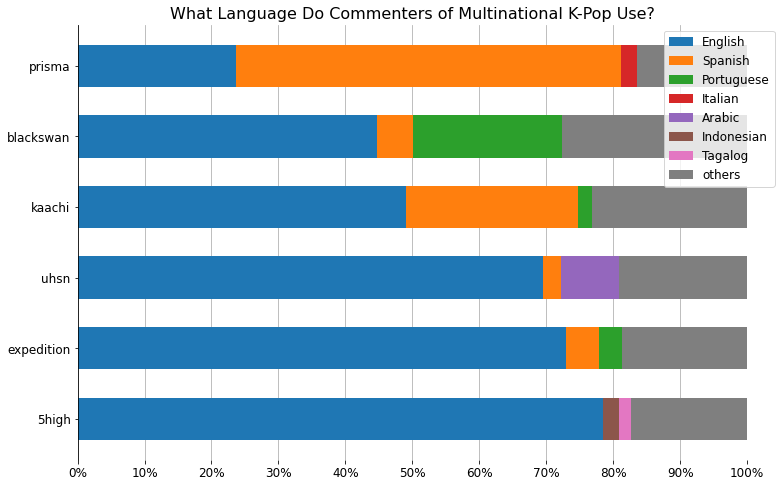

In [4]:
groups = list(df.index)
y_pos = np.arange(len(groups))

languages = list(df.columns)
data = np.array(df)
data_cum = data.cumsum(axis=1)
language_colors  = cm.get_cmap('tab10').colors

fig, ax = plt.subplots(figsize=(12, 8))

ax.set_title('What Language Do Commenters of Multinational K-Pop Use?', fontsize=16)

ax.set_xlim([0, 100])
ax.set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

ax.invert_yaxis()

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

for i, (lang, color) in enumerate(zip(languages, language_colors)):
    
    widths = data[:, i]
    starts = data_cum[:, i] - widths
    rects = ax.barh(groups, widths, left=starts, height=0.6, label=lang, color=color, zorder = 2)
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False) 

ax.grid('x')
ax.legend(loc='upper right', bbox_to_anchor=(1.05, 1), fontsize=12)

plt.savefig('language_use.png', dpi=300, bbox_inches="tight")
plt.show()

In [5]:
long['date'] = long['date'].apply(lambda x: datetime.datetime.strptime(x, '%Y-%m-%d'))
long.head()

,text,author,date,group,language
0,imagine asking for exo tickets for your birthd...,Annaliese Bain,2016-07-14,expedition,en
1,They're not terrible at singing or anything bu...,Katherine Wells,2017-04-17,expedition,en
2,those weird crying pictures are terrifying wtf,Emily T,2017-04-21,expedition,en
3,Why is literally nobody talking about how they...,mina,2020-04-04,expedition,en
4,i wanna know what kpop idols think about this,johnhyuck,2017-04-18,expedition,en


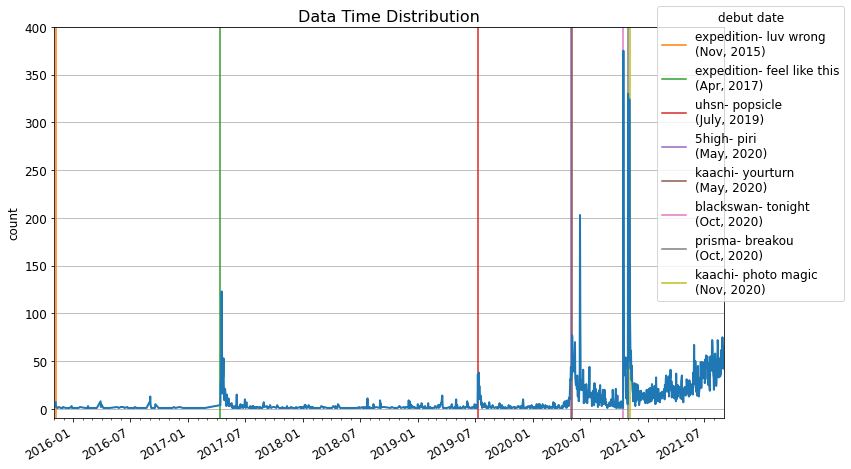

In [6]:
fig, ax = plt.subplots(figsize=(12, 8))

line1 = long['date'].value_counts().sort_index().plot(lw=2, zorder=3, ax=ax, label='_nolegend_')

line2 = ax.plot([datetime.datetime(2015, 11, 7), datetime.datetime(2015, 11, 7)], [-15, 500],
                label='expedition- luv wrong\n(Nov, 2015)', lw=1.5)
line3 = ax.plot([datetime.datetime(2017, 4, 11), datetime.datetime(2017, 4, 11)], [-15, 500],
                label='expedition- feel like this\n(Apr, 2017)', lw=1.5)
line4 = ax.plot([datetime.datetime(2019, 7, 12), datetime.datetime(2019, 7, 12)], [-15, 500],
                label='uhsn- popsicle\n(July, 2019)', lw=1.5)
line5 = ax.plot([datetime.datetime(2020, 5, 3), datetime.datetime(2020, 5, 3)], [-15, 500],
               label='5high- piri\n(May, 2020)', lw=1.5)
line6 = ax.plot([datetime.datetime(2020, 5, 5), datetime.datetime(2020, 5, 5)], [-15, 500],
                label='kaachi- yourturn\n(May, 2020)', lw=1.5)
line7 = ax.plot([datetime.datetime(2020, 10, 16), datetime.datetime(2020, 10, 16)], [-15, 500],
                label='blackswan- tonight\n(Oct, 2020)', lw=1.5)
line8 = ax.plot([datetime.datetime(2020, 10, 31), datetime.datetime(2020, 10, 31)], [-15, 500],
                label='prisma- breakou\n(Oct, 2020)', lw=1.5)
line9 = ax.plot([datetime.datetime(2020, 11, 5), datetime.datetime(2020, 11, 5)], [-15, 500],
                label='kaachi- photo magic\n(Nov, 2020)', lw=1.5)

fmt_half_year = mdates.MonthLocator(interval=6)
ax.xaxis.set_major_locator(fmt_half_year)

fmt_month = mdates.MonthLocator()
ax.xaxis.set_minor_locator(fmt_month)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

ax.set_title('Data Time Distribution', size=16)
ax.set_xlim([datetime.datetime(2015, 11, 1), datetime.datetime(2021, 8, 31)])

ax.set_ylabel('count', fontsize=12)
ax.set_ylim([-10, 400])

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.grid(axis='y')
ax.legend(loc=(0.9, 0.3), title='debut date', fontsize=12, title_fontsize=12)

plt.savefig('data_time_distribution.png', dpi=300, bbox_inches="tight")
plt.show()

***

In [7]:
#loading english-comment-only dataset with results of classification
df = pd.read_pickle('english_comments_with_classification.pickle')
df.head()

,text,author,date,group,language,processed_text,quality,nationalist_ethnicist,kpop
0,imagine asking for exo tickets for your birthd...,Annaliese Bain,2016-07-14,expedition,en,imagine asking exo ticket birthday mom get ins...,0,0,0
1,They're not terrible at singing or anything bu...,Katherine Wells,2017-04-17,expedition,en,terrible singing anything think need kpop much...,0,0,0
2,those weird crying pictures are terrifying wtf,Emily T,2017-04-21,expedition,en,weird cry picture terrifying wtf,0,0,0
3,Why is literally nobody talking about how they...,mina,2020-04-04,expedition,en,literally nobody talking kicked two black guy,0,0,0
4,i wanna know what kpop idols think about this,johnhyuck,2017-04-18,expedition,en,want know kpop idol think,0,0,0


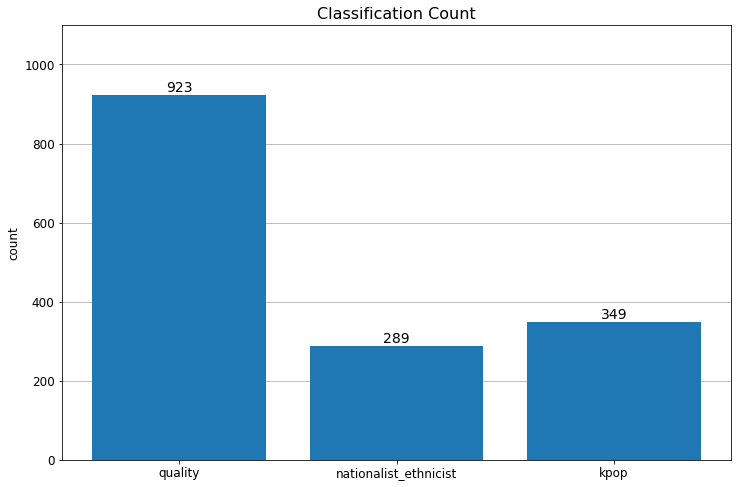

In [8]:
labels = ['quality', 'nationalist_ethnicist', 'kpop']

q = df['quality'].value_counts()[1]
e = df['nationalist_ethnicist'].value_counts()[1]
k = df['kpop'].value_counts()[1]

x = np.arange(len(labels))
y = [q, e, k]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(x, y, zorder=2)

ax.set_title('Classification Count', fontsize=16)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)

ax.set_ylabel('count', fontsize=12)
ax.set_ylim([0, 1100])
ax.tick_params(axis='y', labelsize=12)

ax.bar_label(bars, fontsize=14)
ax.grid(axis='y', zorder=0)

for k, spine in ax.spines.items():  #ax.spines is a dictionary
    spine.set_zorder(10)

plt.savefig('classification_count.png', dpi=300)
plt.show()

In [9]:
# calculate cooccurence

doc = list()

for text in df['processed_text']:
    
    sentences = sent_tokenize(text)
    for s in sentences:
        doc.append(s)
        
concept_list = [('music', 'song'), ('voice', 'vocal'), ('dance', 'choreography'), ('language',),
            ('asian',), ('indian',), ('white',), ('black',), ('race',), ('kpop',), ('training',), ('company',)]

node_list = ['song', 'voice', 'dance', 'language', 'asian', 'indian', 'white', 'black', 'race',
             'kpop', 'training', 'company']

cc = combinations(concept_list, 2)

dd = list()

for o, t in cc:
    dd.append([o, t, np.nan])

for node in dd:
    node[2] = 0
    
    for sentence in doc:
        
        if (any(word in sentence for word in node[0])) & (any(word in sentence for word in node[1])):
            node[2] += 1

############################################

node_dict = dict()
for c, n in zip(concept_list, node_list):
    node_dict[c] = n
    
for i in dd:
    i[0] = node_dict[i[0]]
    i[1] = node_dict[i[1]]

#dd list structure
dd[:6]

[['song', 'voice', 127],
 ['song', 'dance', 75],
 ['song', 'language', 67],
 ['song', 'asian', 50],
 ['song', 'indian', 46],
 ['song', 'white', 26]]

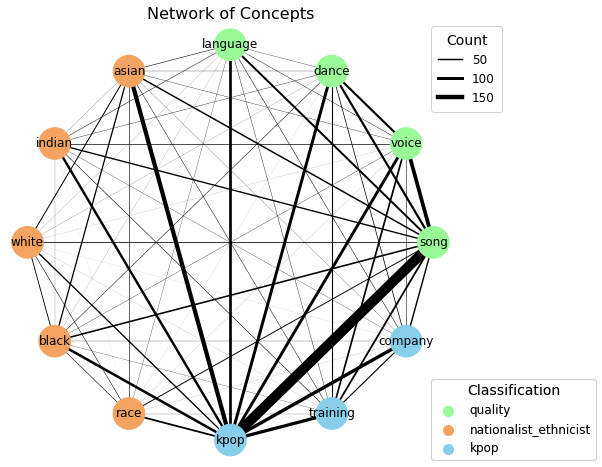

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))

G = nx.Graph()

node_list = node_list
for node in node_list:
    G.add_node(node)
    
group_attr_dict = {'song': 'quality', 'voice': 'quality', 'dance': 'quality', 'language': 'quality',
                   'asian': 'nationalist_ethnicist', 'indian': 'nationalist_ethnicist',
                   'white': 'nationalist_ethnicist', 'black': 'nationalist_ethnicist',
                   'race': 'nationalist_ethnicist',
                   'kpop': 'kpop', 'training': 'kpop', 'company': 'kpop'}

nx.set_node_attributes(G, group_attr_dict, name='group')

node_color = list()

for node in G.nodes(data=True):
    
    if 'quality' in node[1]['group']:
        node_color.append('palegreen')

    elif 'nationalist_ethnicist' in node[1]['group']:
        node_color.append('sandybrown')

    elif 'kpop' in node[1]['group']:
        node_color.append('skyblue')
        
pos=nx.circular_layout(G) 
nx.draw_networkx_nodes(G,pos,node_color=node_color,node_size=1000)

labels = {}
for node_name in node_list:
    labels[str(node_name)] =str(node_name)

nx.draw_networkx_labels(G,pos,labels,font_size=12)

for i in range(len(dd)):

    interaction = dd[i]
    a = interaction[0]
    b = interaction[1]
    w = interaction[2]
    G.add_edge(a, b, weight=w)
    
all_weights = []

for (node1,node2,data) in G.edges(data=True):
    all_weights.append(data['weight'])
    
unique_weights = list(set(all_weights))

for weight in unique_weights:

    weighted_edges = [(node1,node2) for (node1,node2,edge_attr) in G.edges(data=True) if edge_attr['weight']==weight]
    width = (weight/max(unique_weights))*10
    nx.draw_networkx_edges(G,pos,edgelist=weighted_edges,width=width)

for c, l in zip(['palegreen', 'sandybrown', 'skyblue'], ['quality', 'nationalist_ethnicist', 'kpop']):
    plt.scatter([],[], s=100, c=c, label=l)

ax.set_title('Network of Concepts', fontsize=16)

al = ax.legend(loc=(0.95, 0), title='Classification', fontsize=12, title_fontsize=14)
ax.add_artist(al)
ax.axis('off')

ax2 = ax.twinx()
for weight in [50, 100, 150]:
    ax2.plot([], [], c='black', lw=(weight/max(unique_weights))*10, label=str(weight))
ax2.get_yaxis().set_visible(False)

ax2.legend(loc=(0.95, 0.8), title='Count', borderpad=0.6,
           fontsize=12, title_fontsize=14)
ax2.axis('off')

plt.savefig('network_of_concepts.png', dpi=300, bbox_inches="tight")
plt.show()

In [11]:
qualities = df.loc[df['quality']==1, 'text'].sample(3).to_list()
nes = df.loc[df['nationalist_ethnicist']==1, 'text'].sample(3).to_list()
kpops  = df.loc[df['kpop']==1, 'text'].sample(3).to_list()

def no_line(text):
    text = re.sub('[\n]', ' ', text)
    return text

samples = pd.DataFrame(list(zip(qualities, nes, kpops)), columns=['quality', ' nationalist_ethnicist', 'kpop'])
samples = samples.applymap(no_line)

pd.set_option('display.max_colwidth', 300)
samples

,quality,nationalist_ethnicist,kpop
0,"one day, those haters gonna regret hating this group. they truly serving those vocal, visual, and courage! their willingness to learn Korean, not just because they want to debut but because they really love Kpop and want to be a part of it. they just a group of talented people who love Kpop and...","I really hope they don't ""force"" an oversexual style or try to gain too much attention on Fatou and Leia (just because they are foreign) forgetting the other girls. Loved the MV! Wish the girls very luck!","@Shing Mang You are and kpop does not only caters to Asian people, look at black swan, the group has black girl in it and UHSN. Kpop itself is heavily influenced by western pop, even the style like rap and hiphop that kpop is known for originated from other country/race; heck they would even go ..."
1,"Quite mediocre, but if they'll make this girl group a permanent, then I guess they can be a pretty good group. They have the potential... The song is bop... And I know that this isn't their full showcase of talent","@Felix Pence first of all- no. Im happy and im going to express my happiness as much as i want. 2. YOU need to hush bc i am black for ur information & ur being negative over nothing. 3. it really isn't, it can show that kpop can open to more races than Asian + why are u saying that like its a ba...","Dani is SO no facial expression. Possibly she didn't know that acting is, say, a ""requirement"" for a Kpop group, even because facial expression is something that is necessary. Chunseo has a very nasal voice and her Korean pronunciation is totally strange. She may be pretty, but I think it need..."
2,Bruh I think that is not possible because all bollywood does is copy old songs.. it could be possible if you consider south indian music cuz they dont like coping.. and also india has soo many music styles it is next to impossible for a band and also the ego indians have.... and also you should ...,"Hey guys, I just watched this video and I have to say I am so impressed with your work! Thanks a lot for loving K-pop, I hope that people realize that K-pop is open to all race and cultures...Please be generous and patient with some of my fellow Korean people, we are culturally defensive against...","Lord Jiyeoen I can't tell if you're being serious or not, because your post has me laughing so hard. ""What if you were white and wanted to be kpop idol!"" lolololol You can't be serious girlie. I swear to god, white people, stop it. Just stop it.....and while you're at it, try to value Asians and..."


In [12]:
analyzer = SentimentIntensityAnalyzer()

def customize_vader_sentiment():

    custom_sentiment = {
                        'fighting': 2.0,
                        'koreaboo': -2.0,
                        'cringe': -2.0,
                        }

    analyzer.lexicon.update(custom_sentiment)

def vader_sentiment_type(sentence):

    sentiment_dict = analyzer.polarity_scores(sentence)

    score = sentiment_dict['compound']
    
    if score > 0:
        pred_sentiment = 'pos'
    elif score == 0:
        pred_sentiment = 'neu'
    else:
        pred_sentiment = 'neg'
        
    return pred_sentiment

def aspect_based_sentiment_analysis(dataframe, lexicons_of_aspects):
    
    #
    # example of parameters:
    #
    # lexicons_of_aspects = {'song': ['song', 'music'],
    #                       'vocal': ['voice', 'vocal'],
    #                       'dance': ['dance', 'choreography'],
    #                       'language': ['language']}
    #
    
    aspects_list = list(lexicons_of_aspects.keys())
    
    sentiment_dic = dict()
    for i in aspects_list:
        sentiment_dic[i] = list()    

    for i, r in dataframe.iterrows():
    
        who = r['group']
        doc = sent_tokenize(r['text'])
        
        for sent in doc:
            sent = sent.lower()
            
            for j in range(len(lexicons_of_aspects)):
            
                for v in lexicons_of_aspects[aspects_list[j]]:
                
                    if v in sent:
                        ps = vader_sentiment_type(sent)
                        sentiment_dic[aspects_list[j]].append((ps, who))

    return sentiment_dic

def group_sentiment_percentage_calculator(sentiment_dic):
    
    group_dic = dict()
    
    for who in list(df['group'].unique()):
        
        group_dic[who] = list()
    
    for aspect, lst in sentiment_dic.items():
                
        for ps, who in lst:
            
            group_dic[who].append(ps)
            
    for who, lst in group_dic.items():
        
        size = len(lst)
        neg = lst.count('neg')
        neu = lst.count('neu')
        pos = lst.count('pos')
        
        temp = [neg/size, neu/size, pos/size]
        temp = [100*round(i, 3) for i in temp]
        group_dic[who] = temp
        
    return group_dic

def negative_distribution(sentiment_dic):
    
    group_dic = dict()
    aspect_list = list()
    
    for who in list(df['group'].unique()):
        
        group_dic[who] =  dict()
        group_dic[who]['count'] = list()
        group_dic[who]['perc'] = list()
    
    for aspect, lst in sentiment_dic.items():
        aspect_list.append(aspect)
        
        for ps, who in lst:
            
            if ps == 'neg':
                
                group_dic[who]['count'].append(aspect)
                group_dic[who]['perc'].append(aspect)
                
    for g, dic in group_dic.items():
        
        count_dic = dict()
        
        for aspect in aspect_list:
            
            ac = dic['count'].count(aspect)
            count_dic[aspect] = ac
            
        group_dic[g]['count'] = count_dic
        
        perc_dic = dict()
        size = len(dic['perc'])
        
        for aspect in aspect_list:
        
            ac = dic['perc'].count(aspect)
            perc_dic[aspect] = ac/size
            
        group_dic[g]['perc'] = perc_dic
        
    return group_dic

In [13]:
lexicons_of_aspects = {'song': ['song', 'music'],
                           'vocal': ['voice', 'vocal'],
                           'dance': ['dance', 'choreography'],
                           'language': ['language', 'fluent']}

sentiment_dic = aspect_based_sentiment_analysis(df, lexicons_of_aspects)

In [14]:
group_dic = group_sentiment_percentage_calculator(sentiment_dic)

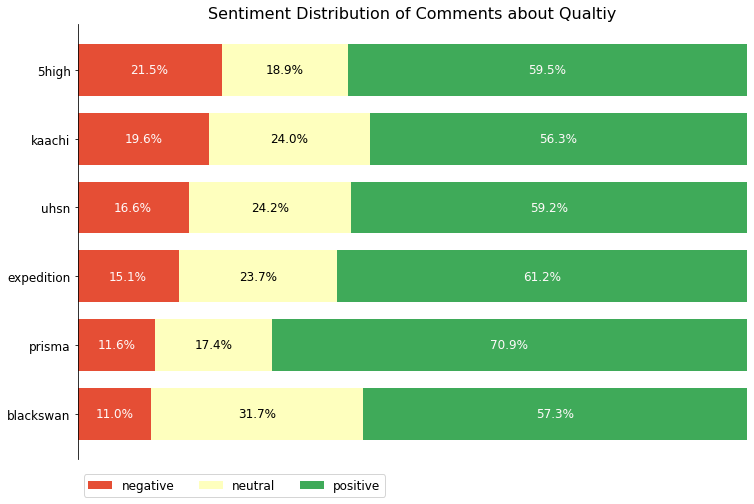

In [15]:
category_names = ['negative', 'neutral', 'positive']
results = dict(sorted(group_dic.items(), key=lambda item: item[1][0]))

def survey(results, category_names):

    labels = list(results.keys())
    
    data = np.array(list(results.values()))
    data_cum = data.cumsum(axis=1)
    
    category_colors = plt.get_cmap('RdYlGn')(
        np.linspace(0.15, 0.85, data.shape[1]))

    fig, ax = plt.subplots(figsize=(12, 8))
    #ax.invert_yaxis()
    ax.xaxis.set_visible(False)
    ax.set_xlim(0, np.sum(data, axis=1).max())
    ax.tick_params(axis='y', labelsize=12)

    for i, (colname, color) in enumerate(zip(category_names, category_colors)):
        widths = data[:, i]
        starts = data_cum[:, i] - widths
        rects = ax.barh(labels, widths, left=starts, height=0.75,
                        label=colname, color=color)

        r, g, b, _ = color
        text_color = 'snow' if r * g * b < 0.5 else 'black'
        ax.bar_label(rects, label_type='center', color=text_color, fmt='%.1f%%', fontsize=12)
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
     
    ax.legend(ncol=len(category_names), bbox_to_anchor=(0, -0.1),
              loc='lower left', fontsize=12)
    
    ax.set_title('Sentiment Distribution of Comments about Qualtiy', fontsize=16)
    
    for k, spine in ax.spines.items():  #ax.spines is a dictionary
        spine.set_zorder(10)

    return fig, ax

survey(results, category_names)
plt.savefig('quality_sentiment_distribution.png', dpi=300)
plt.show()

In [16]:
group_dic = negative_distribution(sentiment_dic)

points = list()

counts = list()
for g, d in group_dic.items():
    for k, v in d['count'].items():
        counts.append(v)
m = max(counts)


for group, d in group_dic.items():
    
    for aspect in d['perc']:
        
        perc = d['perc'][aspect]
        count = d['count'][aspect]
        weight = count/m
        
        point = (perc, group, aspect, weight)
        points.append(point)

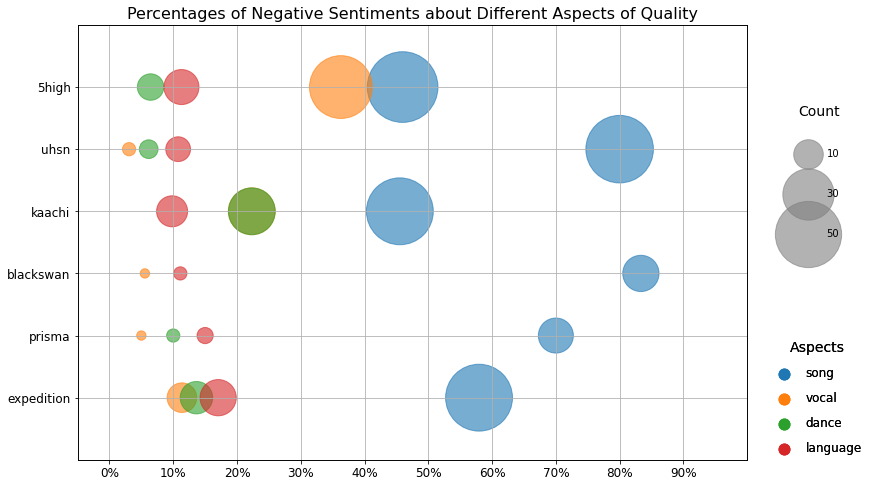

In [17]:
#with a given data points (x, y, aspect, weight)

group_list = ['expedition', 'prisma', 'blackswan', 'kaachi', 'uhsn', '5high']
aspect_list = ['song', 'vocal', 'dance', 'language']

def aspect_to_c(x):
    
    dic = dict()
    for a, c in zip(aspect_list, ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']):
        dic[a] = c
    return(dic[x])

x = [a*100 for (a, b, c, d) in points]
y = [b for (a, b, c, d) in points]
aspect = [aspect_to_c(c) for (a, b, c, d) in points]
size = [d*5000 for (a, b, c, d) in points]

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(x, y, c=aspect, s=size, alpha=0.6)

ax.set_title('Percentages of Negative Sentiments about Different Aspects of Quality', fontsize=16)

ax.set_xlim([-5, 100])
ax.set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90])
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

ax.set_ylim([-1, 6])

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.grid(True)

for a in aspect_list:
    ax.scatter([],[], s=120, c=aspect_to_c(a), label=a)

al = ax.legend(loc=(1.03, 0), fontsize=12, frameon=False, labelspacing=1,
               title='Aspects', title_fontsize=14)
ax.add_artist(al)

ax2 = ax.twinx()
for count in [10, 30, 50]:
    ax2.scatter([], [], c='tab:grey', alpha=0.6, s=count/m*5000, label=str(count))
ax2.get_yaxis().set_visible(False)

ax2.legend(loc=(1.07, 0.5), labelspacing=3, frameon=False, title='Count',
           fontsize=10, title_fontsize=14)

plt.savefig('negative_quality.png', dpi=300, bbox_inches="tight")
plt.show()

In [18]:
lexicons_of_aspects = {'asian': ['asian'],
                           'indian': ['indian'],
                           'white': ['white'],
                           'black': ['black'],
                            'race': ['race']}

sentiment_dic = aspect_based_sentiment_analysis(df, lexicons_of_aspects)

In [19]:
group_dic = group_sentiment_percentage_calculator(sentiment_dic)

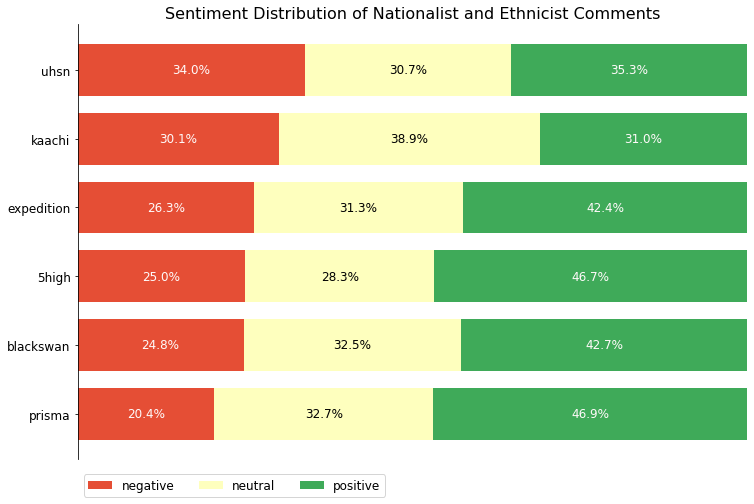

In [20]:
category_names = ['negative', 'neutral', 'positive']
results = dict(sorted(group_dic.items(), key=lambda item: item[1][0]))

def survey(results, category_names):

    labels = list(results.keys())
    
    data = np.array(list(results.values()))
    data_cum = data.cumsum(axis=1)
    
    category_colors = plt.get_cmap('RdYlGn')(
        np.linspace(0.15, 0.85, data.shape[1]))

    fig, ax = plt.subplots(figsize=(12, 8))
    #ax.invert_yaxis()
    ax.xaxis.set_visible(False)
    ax.set_xlim(0, np.sum(data, axis=1).max())
    ax.tick_params(axis='y', labelsize=12)

    for i, (colname, color) in enumerate(zip(category_names, category_colors)):
        widths = data[:, i]
        starts = data_cum[:, i] - widths
        rects = ax.barh(labels, widths, left=starts, height=0.75,
                        label=colname, color=color)

        r, g, b, _ = color
        text_color = 'snow' if r * g * b < 0.5 else 'black'
        ax.bar_label(rects, label_type='center', color=text_color, fmt='%.1f%%', fontsize=12)
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
     
    ax.legend(ncol=len(category_names), bbox_to_anchor=(0, -0.1),
              loc='lower left', fontsize=12)
    
    ax.set_title('Sentiment Distribution of Nationalist and Ethnicist Comments', fontsize=16)
    
    for k, spine in ax.spines.items():  #ax.spines is a dictionary
        spine.set_zorder(10)

    return fig, ax

survey(results, category_names)
plt.savefig('nationalist_ethnicist_sentiment_distribution', dpi=300, )
plt.show()

In [21]:
lexicons_of_aspects = {'asian': ['asian'],
                           'indian': ['indian'],
                           'white': ['white'],
                           'black': ['black'],
                            'race': ['race']}

sentiment_dic = aspect_based_sentiment_analysis(df, lexicons_of_aspects)

In [22]:
def sentiment_distribution_by_aspect(sentiment_dic):
        
    # (perc, aspect, sent_type, count)
    
    results = dict()    
    aspect_dic = dict()
    
    for aspect in sentiment_dic:
        
        results[aspect] = dict()
        aspect_dic[aspect] = list()

    for aspect, lst in sentiment_dic.items():
        
        for ps, who in lst:
            aspect_dic[aspect].append(ps)
            
    #aspect_dic = {aspect: [neg, neg, neu, ...]}
                
    for a, lst in aspect_dic.items():
        
        neg_ = list()
        neu_ = list()
        pos_ = list()
            
        size = len(lst)
        
        for ps in lst:
            if ps == 'neg':
                neg_.append(ps)
            if ps == 'neu':
                neu_.append(ps)
            if ps == 'pos':
                pos_.append(ps)
        
        results[a]['neg'] = [len(neg_)/size, len(neg_)]
        results[a]['neu'] = [len(neu_)/size, len(neu_)]
        results[a]['pos'] = [len(pos_)/size, len(pos_)]
        
    return results

In [23]:
points_dic = sentiment_distribution_by_aspect(sentiment_dic)
points_dic

{'asian': {'neg': [0.2647058823529412, 90],
  'neu': [0.3352941176470588, 114],
  'pos': [0.4, 136]},
 'indian': {'neg': [0.2599118942731278, 59],
  'neu': [0.2687224669603524, 61],
  'pos': [0.4713656387665198, 107]},
 'white': {'neg': [0.35668789808917195, 56],
  'neu': [0.2802547770700637, 44],
  'pos': [0.3630573248407643, 57]},
 'black': {'neg': [0.22764227642276422, 84],
  'neu': [0.34417344173441733, 127],
  'pos': [0.4281842818428184, 158]},
 'race': {'neg': [0.3333333333333333, 39],
  'neu': [0.3076923076923077, 36],
  'pos': [0.358974358974359, 42]}}

In [24]:
points = list()

counts = list()
percs = list()
sents = list()
aspects = list()

for a, dic1 in points_dic.items():
    for s, dic2 in dic1.items():
        
        percs.append(round(dic2[0], 3))
        aspects.append(a)
        sents.append(s)
        counts.append(dic2[1])
        
m = max(counts)

weights = [i/m for i in counts]

for p, a, s, w in zip(percs, aspects, sents, weights):
    points.append((p, a, s, w))
    
# poinst = [(perc, aspect, sent_type, count)]

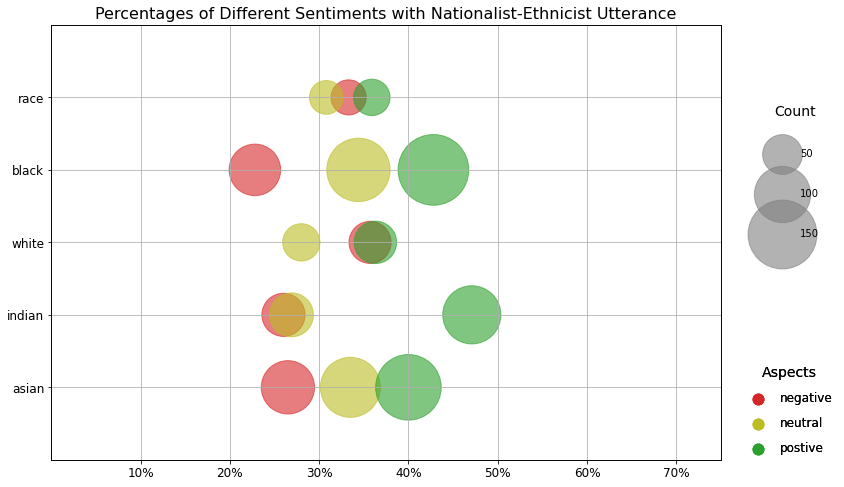

In [25]:
#with a given data points (x, y, aspect, weight)

aspect_list = ['asian', 'indian', 'white', 'black', 'race']
sent_list = ['negative', 'neutral', 'postive']

def s_to_l(x):
    
    dic = dict()
    for s, l in zip(['neg', 'neu', 'pos'], sent_list):
        dic[s] = l
    return dic[x]

def sent_to_c(x):
    
    dic = dict()
    for a, c in zip(sent_list, ['tab:red', 'tab:olive', 'tab:green']):
        dic[a] = c
    return dic[x]

x = [a*100 for (a, b, c, d) in points]
y = [b for (a, b, c, d) in points]
sent = [sent_to_c(s_to_l(c)) for (a, b, c, d) in points]
size = [d*5000 for (a, b, c, d) in points]

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(x, y, c=sent, s=size, alpha=0.6)

ax.set_title('Percentages of Different Sentiments with Nationalist-Ethnicist Utterance', fontsize=16)

ax.set_xlim([0, 75])
ax.set_xticks([10, 20, 30, 40, 50, 60, 70])
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

ax.set_ylim([-1, 5])

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.grid(True)

for a in sent_list:
    ax.scatter([],[], s=120, c=sent_to_c(a), label=a)

al = ax.legend(loc=(1.03, 0), fontsize=12, frameon=False, labelspacing=1,
               title='Aspects', title_fontsize=14)
ax.add_artist(al)

ax2 = ax.twinx()
for count in [50, 100, 150]:
    ax2.scatter([], [], c='tab:grey', alpha=0.6, s=count/m*5000, label=str(count))
ax2.get_yaxis().set_visible(False)

ax2.legend(loc=(1.07, 0.5), labelspacing=3, frameon=False, title='Count',
           fontsize=10, title_fontsize=14)

plt.savefig('nationalist_ethnicist_sentiment_distribution_by_aspect', dpi=300, bbox_inches="tight")
plt.show()